# Semana 06 — Limpeza e Transformação de Dados

**SENAI — Visualização de Dados**

Dados do mundo real raramente chegam limpos. Antes de qualquer gráfico ou análise, o analista precisa identificar e corrigir os problemas mais comuns.

Hoje você vai aprender a fazer isso do zero com Python e pandas.

**O que vamos ver:**

| Bloco | Tema | Tempo estimado |
|---|---|---|
| 0 | Setup e exploração inicial | 15 min |
| 1 | Valores ausentes (NaN) | 45 min |
| 2 | Duplicatas | 20 min |
| 3 | Outliers (valores absurdos) | 25 min |
| 4 | Criando novas colunas | 35 min |
| 5 | Juntando tabelas com `pd.concat()` | 20 min |
| — | Exercício final | 20 min |

## Bloco 0 — Setup: Carregando os Dados

Vamos usar três bibliotecas ao longo da aula:

- `pandas` — manipulação de tabelas
- `numpy` — operações numéricas
- `matplotlib` — gráficos

A base é de **vendas de um supermercado** (250 transações). O arquivo fica na pasta `../base/`, ao lado deste notebook.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../base/base_vendas_supermercado.xlsx")

print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
print(f"Período: {df['Data'].min().date()} até {df['Data'].max().date()}")
print()
print("Colunas disponíveis:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

Linhas: 250 | Colunas: 12
Período: 2026-01-01 até 2026-05-05

Colunas disponíveis:
   1. Data
   2. Loja
   3. Cliente
   4. Categoria
   5. Produto
   6. Quantidade
   7. Preço Unitário
   8. Desconto %
   9. Valor Bruto
  10. Valor Desconto
  11. Valor Líquido
  12. Forma de Pagamento


/Users/samuelbucco/Documents/SCTec/Análise de Dados/Etapa Profissionalizar/Mod 1 - Modelagem de Dados/turma-visualizacao-de-dados/.venv/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/samuelbucco/Documents/SCTec/Análise de Dados/Etapa Profissionalizar/Mod 1 - Modelagem de Dados/turma-visualizacao-de-dados/.venv/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [13]:
# Checklist inicial: estrutura, tipos e estatísticas
print("=== Primeiras 5 linhas ===")
print(df.head().to_string())
print()
print("=== Estrutura e tipos ===")
df.info()
print()
print("=== Estatísticas numéricas ===")
print(df.describe().round(2).to_string())

=== Primeiras 5 linhas ===
        Data           Loja           Cliente   Categoria                Produto  Quantidade  Preço Unitário  Desconto %  Valor Bruto  Valor Desconto  Valor Líquido Forma de Pagamento
0 2026-01-04  Loja Shopping     Cliente Final  Laticínios  Queijo Mussarela 500g           4           23.53        0.00        94.12            0.00          94.12   Vale Alimentação
1 2026-01-04    Loja Centro  Clube Fidelidade   Mercearia     Óleo de Soja 900ml           4            6.97        0.00        27.88            0.00          27.88   Vale Alimentação
2 2026-02-27  Loja Shopping  Clube Fidelidade     Padaria         Pão Francês kg           4           15.84        0.03        63.36            1.90          61.46  Cartão de Crédito
3 2026-01-12     Loja Norte     Cliente Final  Laticínios      Leite Integral 1L           6            6.21        0.03        37.26            1.12          36.14           Dinheiro
4 2026-05-05     Loja Norte  Clube Fidelidade  Laticí

### O que observar nesse checklist?

- **`info()`** mostra se alguma coluna tem valores nulos (*non-null count* menor que o total)
- **`describe()`** mostra mínimos e máximos — valores muito extremos já indicam possíveis outliers
- A base original está limpa — vamos criar problemas propositalmente para praticar

---
## Bloco 1 — Valores Ausentes (NaN)

### O que são valores ausentes?

Em pandas, campos vazios aparecem como **NaN** (*Not a Number*). Eles surgem por vários motivos:

- Operador deixou o campo em branco
- Sistema falhou ao registrar a venda
- Cliente não informou um dado opcional

### Por que isso importa?

Cálculos como `mean()` e `sum()` **ignoram NaN por padrão** — mas visualizações e modelos podem se comportar de forma inesperada. Sempre verifique antes de analisar.

In [14]:
# Criando uma versão "suja" para praticar — nunca modifique a base original!
np.random.seed(42)
df_sujo = df.copy()

nan_config = {
    'Categoria':          15,
    'Preço Unitário':     12,
    'Forma de Pagamento': 10,
    'Quantidade':          8,
}
print(nan_config.items())

for coluna, qtd in nan_config.items():
    idx = np.random.choice(df_sujo.index, size=qtd, replace=False)
    df_sujo.loc[idx, coluna] = np.nan

# Também inserindo duplicatas (usaremos no Bloco 2)
dup = df_sujo.sample(n=12, random_state=7)
df_sujo = pd.concat([df_sujo, dup], ignore_index=True)
df_sujo = df_sujo.sample(frac=1, random_state=3).reset_index(drop=True)

print(f"Base suja criada: {df_sujo.shape[0]} linhas | {df_sujo.isnull().sum().sum()} NaN | {df_sujo.duplicated().sum()} duplicatas")

dict_items([('Categoria', 15), ('Preço Unitário', 12), ('Forma de Pagamento', 10), ('Quantidade', 8)])
Base suja criada: 262 linhas | 48 NaN | 12 duplicatas


In [15]:
# Contando NaN por coluna
nan_por_coluna = df_sujo.isnull().sum()
pct_nan        = (df_sujo.isnull().mean() * 100).round(1)

print("=== Valores ausentes por coluna ===")
for col in df_sujo.columns:
    if nan_por_coluna[col] > 0:
        barras = '█' * int(pct_nan[col] / 2)
        print(f"  {col:<25} {nan_por_coluna[col]:>3} NaN  ({pct_nan[col]:>4.1f}%)  {barras}")

print()
print(f"Total de NaN: {df_sujo.isnull().sum().sum()}")

=== Valores ausentes por coluna ===
  Categoria                  17 NaN  ( 6.5%)  ███
  Quantidade                  9 NaN  ( 3.4%)  █
  Preço Unitário             12 NaN  ( 4.6%)  ██
  Forma de Pagamento         10 NaN  ( 3.8%)  █

Total de NaN: 48


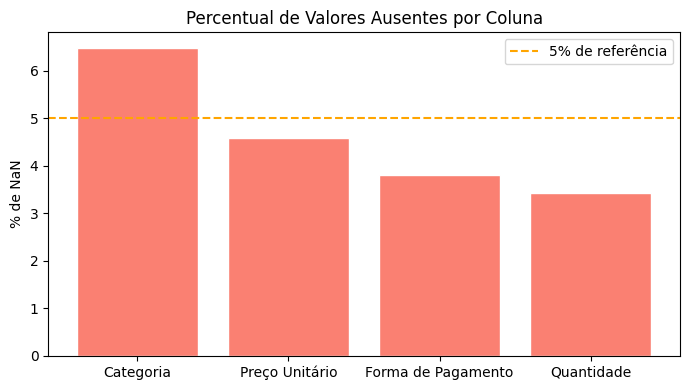

In [16]:
# Gráfico de barras: % de NaN por coluna
pct = df_sujo.isnull().mean() * 100
pct = pct[pct > 0].sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(pct.index, pct.values, color='salmon', edgecolor='white')
plt.axhline(5, color='orange', linestyle='--', linewidth=1.5, label='5% de referência')
plt.title('Percentual de Valores Ausentes por Coluna')
plt.ylabel('% de NaN')
plt.legend()
plt.tight_layout()
plt.show()

### Como tratar valores ausentes?

Escolha a estratégia conforme o tipo de dado:

```
Dado ausente
├── A linha inteira é inútil sem ele?   → dropna(subset=['coluna'])
├── É um texto / categoria?
│   ├── Há um valor padrão claro?       → fillna("Desconhecido")
│   └── Não há padrão claro             → fillna(moda)
└── É um número?
    ├── Sem valores extremos?           → fillna(média)
    └── Com valores extremos?           → fillna(mediana)
```

In [17]:
df_tratado = df_sujo.copy()

# Colunas de texto → preencher com a moda (valor mais frequente)
df_tratado['Categoria']          = df_tratado['Categoria'].fillna(df_tratado['Categoria'].mode()[0])
df_tratado['Forma de Pagamento'] = df_tratado['Forma de Pagamento'].fillna(df_tratado['Forma de Pagamento'].mode()[0])

# Colunas numéricas → preencher com a mediana
df_tratado['Preço Unitário'] = df_tratado['Preço Unitário'].fillna(df_tratado['Preço Unitário'].median())
df_tratado['Quantidade']     = df_tratado['Quantidade'].fillna(df_tratado['Quantidade'].median())

print(f"NaN restantes: {df_tratado.isnull().sum().sum()}")
print()
print("Verificação por coluna:")
print(df_tratado.isnull().sum().to_string())

NaN restantes: 0

Verificação por coluna:
Data                  0
Loja                  0
Cliente               0
Categoria             0
Produto               0
Quantidade            0
Preço Unitário        0
Desconto %            0
Valor Bruto           0
Valor Desconto        0
Valor Líquido         0
Forma de Pagamento    0


> **`dropna()` quando usar?**
>
> Se uma coluna essencial (como `'Valor Líquido'`) tiver NaN, a linha inteira pode ser descartada:
>
> ```python
> df_sem_nan = df_sujo.dropna(subset=['Valor Líquido'])
> ```
>
> Sem `subset`, o `dropna()` remove qualquer linha com **pelo menos um** NaN — cuidado para não perder dados demais.

---
## Bloco 2 — Duplicatas

### O que são duplicatas?

Uma **duplicata** é um registro que aparece mais de uma vez. Causas comuns:
- Planilha importada duas vezes por engano
- Sistema registrou a mesma transação duas vezes

Em vendas, duplicatas inflam o faturamento e distorcem relatórios.

- `duplicated()` → identifica as linhas repetidas (retorna `True` na 2ª ocorrência em diante)
- `drop_duplicates()` → remove, mantendo a primeira ocorrência

In [18]:
# Identificando duplicatas
dup_mask = df_sujo.duplicated()
print(f"Total de duplicatas: {dup_mask.sum()}")
print()

# Exemplo das duplicatas encontradas
print("Primeiras 4 duplicatas:")
print(df_sujo[dup_mask][['Data', 'Loja', 'Produto', 'Quantidade', 'Valor Líquido']].head(4).to_string())

Total de duplicatas: 12

Primeiras 4 duplicatas:
          Data              Loja               Produto  Quantidade  Valor Líquido
62  2026-02-15       Loja Centro               Maçã kg         4.0          39.88
98  2026-01-12        Loja Norte     Leite Integral 1L         6.0          36.14
126 2026-02-04  Loja Bairro Alto  Linguiça Toscana 1kg         4.0          88.24
136 2026-03-27       Loja Centro             Batata kg         4.0          26.30


In [19]:
# Removendo duplicatas
df_sem_dup = df_sujo.drop_duplicates()

print(f"Antes : {len(df_sujo)} linhas")
print(f"Depois: {len(df_sem_dup)} linhas")
print(f"Removidas: {len(df_sujo) - len(df_sem_dup)} duplicatas")
print(f"Duplicatas restantes: {df_sem_dup.duplicated().sum()}")

Antes : 262 linhas
Depois: 250 linhas
Removidas: 12 duplicatas
Duplicatas restantes: 0


In [20]:
# ── Pipeline: aplicar limpeza completa (NaN + duplicatas) ─────────────────
df_limpo = df_sujo.copy()

# 1. Remover duplicatas
df_limpo = df_limpo.drop_duplicates()

# 2. Tratar NaN de texto com moda
df_limpo['Categoria']          = df_limpo['Categoria'].fillna(df_limpo['Categoria'].mode()[0])
df_limpo['Forma de Pagamento'] = df_limpo['Forma de Pagamento'].fillna(df_limpo['Forma de Pagamento'].mode()[0])

# 3. Tratar NaN numéricos com mediana
df_limpo['Preço Unitário'] = df_limpo['Preço Unitário'].fillna(df_limpo['Preço Unitário'].median())
df_limpo['Quantidade']     = df_limpo['Quantidade'].fillna(df_limpo['Quantidade'].median()).astype(int)

print(f"{'Base Suja':<20} {df_sujo.shape[0]:>4} linhas | {df_sujo.isnull().sum().sum():>2} NaN | {df_sujo.duplicated().sum():>2} dup")
print(f"{'Base Limpa':<20} {df_limpo.shape[0]:>4} linhas | {df_limpo.isnull().sum().sum():>2} NaN | {df_limpo.duplicated().sum():>2} dup")

Base Suja             262 linhas | 48 NaN | 12 dup
Base Limpa            250 linhas |  0 NaN |  0 dup


---
## Bloco 3 — Outliers: Valores Absurdos

### O que é um outlier?

Um **outlier** é um valor que está muito longe dos demais. Pode ser:
- **Erro de digitação** → R$ 850 em vez de R$ 8,50
- **Bug do sistema** → valor multiplicado por 100
- **Evento real excepcional** → promoção relâmpago

### Por que isso é um problema?

Um único valor absurdo pode puxar a média para longe da realidade e gerar análises erradas.

### Como identificar?

O **boxplot** mostra os outliers como pontos isolados fora da "caixa".

In [21]:
# Inserindo valores absurdos para praticar
np.random.seed(99)
df_out = df_limpo.copy()

idx_altos  = np.random.choice(df_out.index, 4, replace=False)
idx_baixos = np.random.choice(df_out.index, 3, replace=False)

df_out.loc[idx_altos,  'Valor Líquido'] = [850.0, 1200.0, 980.0, 760.0]
df_out.loc[idx_baixos, 'Valor Líquido'] = [0.50, 0.30, 0.10]

print(f"Com outliers: mín = R$ {df_out['Valor Líquido'].min():.2f} | máx = R$ {df_out['Valor Líquido'].max():.2f}")
print(f"Sem outliers: mín = R$ {df_limpo['Valor Líquido'].min():.2f} | máx = R$ {df_limpo['Valor Líquido'].max():.2f}")

Com outliers: mín = R$ 0.10 | máx = R$ 1200.00
Sem outliers: mín = R$ 2.95 | máx = R$ 197.36


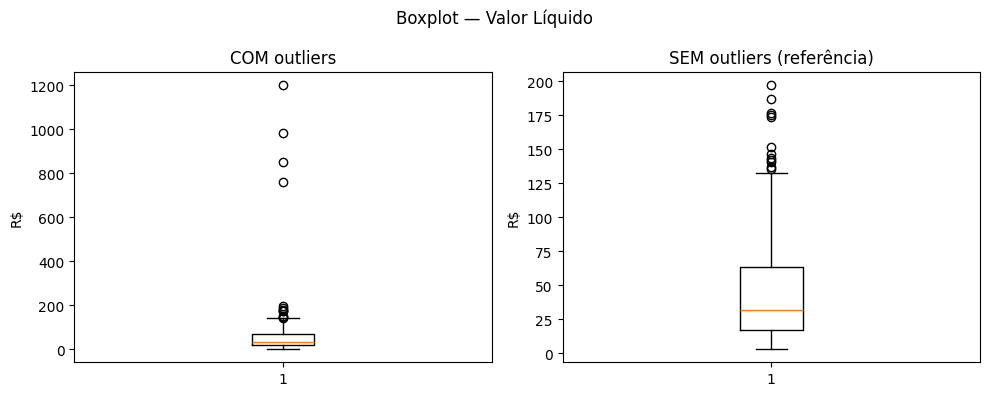

In [22]:
# Boxplot: os pontos soltos fora da caixa são os outliers
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df_out['Valor Líquido'])
axes[0].set_title('COM outliers')
axes[0].set_ylabel('R$')

axes[1].boxplot(df_limpo['Valor Líquido'])
axes[1].set_title('SEM outliers (referência)')
axes[1].set_ylabel('R$')

plt.suptitle('Boxplot — Valor Líquido')
plt.tight_layout()
plt.show()

---
### Como ler um Boxplot?

```
         │
    ┌────┴────┐   ← 75% dos dados estão abaixo desta linha
    │         │
    │  ─────  │   ← Mediana (50%)
    │         │
    └────┬────┘   ← 25% dos dados estão abaixo desta linha
         │
    ○ ○ ○        ← Outliers (pontos isolados e distantes)
```

Os pontos **soltos e bem afastados** da caixa são os outliers. No gráfico da esquerda você vê os pontos em R$ 760–1200 no topo e os centavos na base.

In [23]:
# Filtrando: mantendo apenas valores num intervalo razoável
# (decisão baseada no negócio: compras entre R$ 1 e R$ 300)
df_filtrado = df_out[
    (df_out['Valor Líquido'] >= 1) &
    (df_out['Valor Líquido'] <= 300)
].copy()

print(f"Antes : {len(df_out)} linhas | Média: R$ {df_out['Valor Líquido'].mean():.2f}")
print(f"Depois: {len(df_filtrado)} linhas | Média: R$ {df_filtrado['Valor Líquido'].mean():.2f}")
print(f"Removidas: {len(df_out) - len(df_filtrado)} linhas")

Antes : 250 linhas | Média: R$ 60.14
Depois: 243 linhas | Média: R$ 46.28
Removidas: 7 linhas


---
## Bloco 4 — Criando Novas Colunas

### Por que criar colunas novas?

Os dados raramente chegam no formato ideal. Precisamos extrair informações úteis:
- Da coluna `Data` → extrair o **mês** ou o **dia da semana**
- Do `Valor Líquido` → classificar em faixas (baixo, médio, alto)
- De qualquer texto → padronizar, transformar

**Três ferramentas essenciais:**

| Ferramenta | Para que serve |
|---|---|
| `.dt.month`, `.dt.day_name()` | Extrair partes de datas |
| `.apply(lambda x: ...)` | Aplicar qualquer lógica simples linha a linha |
| `pd.cut()` | Dividir números em faixas com rótulos |

### Extraindo informações de datas

Colunas do tipo `datetime` têm um acessor `.dt` com vários atributos úteis:

| Código | Retorna |
|---|---|
| `.dt.month` | Número do mês (1 a 12) |
| `.dt.day_name()` | Nome do dia da semana (em inglês) |
| `.dt.strftime('%B')` | Nome do mês por extenso |

In [24]:
df_transf = df_filtrado.copy()

df_transf['Mês']        = df_transf['Data'].dt.month
df_transf['Nome_Mês']   = df_transf['Data'].dt.strftime('%B')
df_transf['Dia_Semana'] = df_transf['Data'].dt.day_name()

print(df_transf[['Data', 'Mês', 'Nome_Mês', 'Dia_Semana']].head(6).to_string(index=False))

      Data  Mês Nome_Mês Dia_Semana
2026-03-14    3    March   Saturday
2026-05-01    5      May     Friday
2026-01-31    1  January   Saturday
2026-02-28    2 February   Saturday
2026-04-11    4    April   Saturday
2026-02-06    2 February     Friday


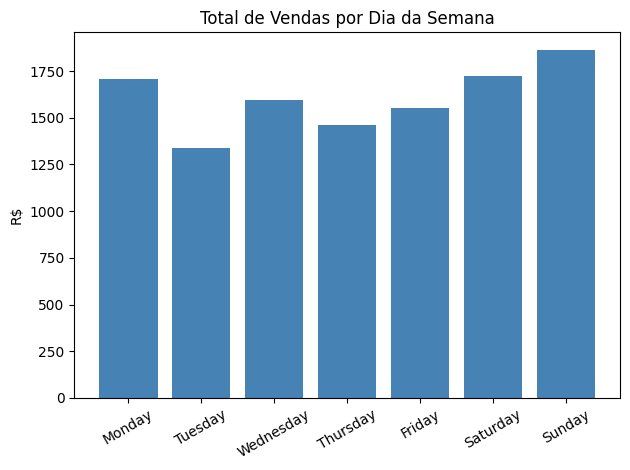

In [25]:
# Qual dia da semana gera mais vendas?
vendas_dia = df_transf.groupby('Dia_Semana')['Valor Líquido'].sum()
ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
vendas_dia = vendas_dia.reindex([d for d in ordem if d in vendas_dia.index])

plt.bar(vendas_dia.index, vendas_dia.values, color='steelblue')
plt.title('Total de Vendas por Dia da Semana')
plt.ylabel('R$')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### `apply()` com lambda

`apply()` aplica uma função a cada elemento de uma coluna. Com **lambda** fazemos isso em uma linha:

```python
coluna.apply(lambda x: <o que fazer com x>)
```

Exemplos:
- `lambda x: x.upper()` → texto em maiúsculas
- `lambda x: 'Grande' if x > 100 else 'Pequena'` → condição simples

In [26]:
# Lambda: texto em maiúsculas
df_transf['Loja_Upper'] = df_transf['Loja'].apply(lambda x: x.upper())

# Função nomeada: classificar tamanho da compra
def classificar_compra(valor):
    if valor < 20:
        return 'Pequena'
    elif valor < 60:
        return 'Média'
    else:
        return 'Grande'

df_transf['Tamanho_Compra'] = df_transf['Valor Líquido'].apply(classificar_compra)

print(df_transf[['Valor Líquido', 'Tamanho_Compra', 'Loja', 'Loja_Upper']].head(6).to_string(index=False))

 Valor Líquido Tamanho_Compra             Loja       Loja_Upper
          6.32        Pequena      Loja Centro      LOJA CENTRO
          6.45        Pequena      Loja Centro      LOJA CENTRO
         69.69         Grande Loja Bairro Alto LOJA BAIRRO ALTO
         71.78         Grande    Loja Shopping    LOJA SHOPPING
        124.58         Grande    Loja Shopping    LOJA SHOPPING
         21.73          Média       Loja Norte       LOJA NORTE


### `pd.cut()`: Faixas de Valores

`pd.cut()` divide uma coluna numérica em faixas definidas por você — sem precisar de if/elif/else:

```python
pd.cut(coluna, bins=[limites], labels=['rótulos'])
```

> O número de rótulos deve ser **1 a menos** que o número de limites.
> Exemplo: `bins=[0, 20, 60, 300]` → 3 intervalos → 3 rótulos.

In [27]:
df_transf['Faixa_Ticket'] = pd.cut(
    df_transf['Valor Líquido'],
    bins=[0, 20, 60, 120, 300],
    labels=['Baixo', 'Médio', 'Alto', 'Premium']
)

print("Compras por faixa:")
print(df_transf['Faixa_Ticket'].value_counts().sort_index().to_string())

Compras por faixa:
Faixa_Ticket
Baixo      74
Médio      97
Alto       52
Premium    20


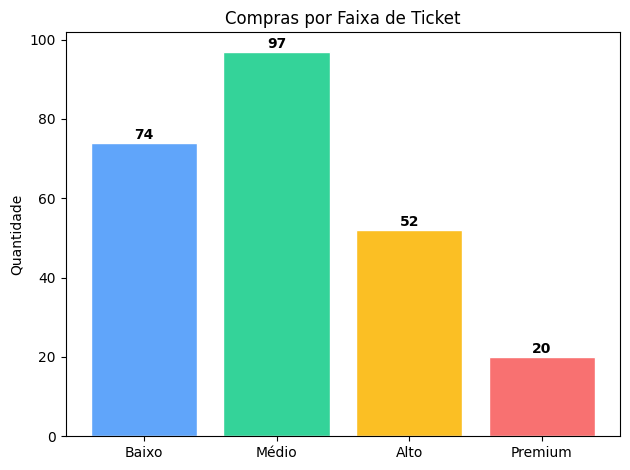

In [28]:
faixas = df_transf['Faixa_Ticket'].value_counts().sort_index()
cores  = ['#60a5fa', '#34d399', '#fbbf24', '#f87171']

plt.bar(faixas.index, faixas.values, color=cores, edgecolor='white')
for i, v in enumerate(faixas.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.title('Compras por Faixa de Ticket')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

---
## Bloco 5 — Juntando Tabelas com `pd.concat()`

### Quando precisamos disso?

Imagine receber os dados de **Janeiro**, **Fevereiro** e **Março** em arquivos separados. Para analisar o trimestre, precisamos **empilhar** os três DataFrames — um embaixo do outro.

```python
pd.concat([df1, df2, df3], ignore_index=True)
```

> `ignore_index=True` reinicia a numeração das linhas. Sem isso, os índices ficam duplicados.

In [29]:
# Dividindo a base por mês para simular arquivos separados
df_temp = df.copy()
df_temp['Mes'] = df_temp['Data'].dt.month

df_jan = df_temp[df_temp['Mes'] == 1].drop(columns='Mes').reset_index(drop=True)
df_fev = df_temp[df_temp['Mes'] == 2].drop(columns='Mes').reset_index(drop=True)
df_mar = df_temp[df_temp['Mes'] == 3].drop(columns='Mes').reset_index(drop=True)

print(f"Janeiro  : {len(df_jan)} vendas")
print(f"Fevereiro: {len(df_fev)} vendas")
print(f"Março    : {len(df_mar)} vendas")

Janeiro  : 61 vendas
Fevereiro: 59 vendas
Março    : 60 vendas


In [30]:
# Empilhando os três meses em um único DataFrame
df_trimestre = pd.concat([df_jan, df_fev, df_mar], ignore_index=True)

print(f"Trimestre: {df_trimestre.shape[0]} linhas x {df_trimestre.shape[1]} colunas")
print()
print("Primeiras linhas (Janeiro):")
print(df_trimestre.head(3).to_string(index=False))
print()
print("Últimas linhas (Março):")
print(df_trimestre.tail(3).to_string(index=False))

Trimestre: 180 linhas x 12 colunas

Primeiras linhas (Janeiro):
      Data          Loja          Cliente  Categoria               Produto  Quantidade  Preço Unitário  Desconto %  Valor Bruto  Valor Desconto  Valor Líquido Forma de Pagamento
2026-01-04 Loja Shopping    Cliente Final Laticínios Queijo Mussarela 500g           4           23.53        0.00        94.12            0.00          94.12   Vale Alimentação
2026-01-04   Loja Centro Clube Fidelidade  Mercearia    Óleo de Soja 900ml           4            6.97        0.00        27.88            0.00          27.88   Vale Alimentação
2026-01-12    Loja Norte    Cliente Final Laticínios     Leite Integral 1L           6            6.21        0.03        37.26            1.12          36.14           Dinheiro

Últimas linhas (Março):
      Data             Loja          Cliente Categoria             Produto  Quantidade  Preço Unitário  Desconto %  Valor Bruto  Valor Desconto  Valor Líquido Forma de Pagamento
2026-03-29       Loja

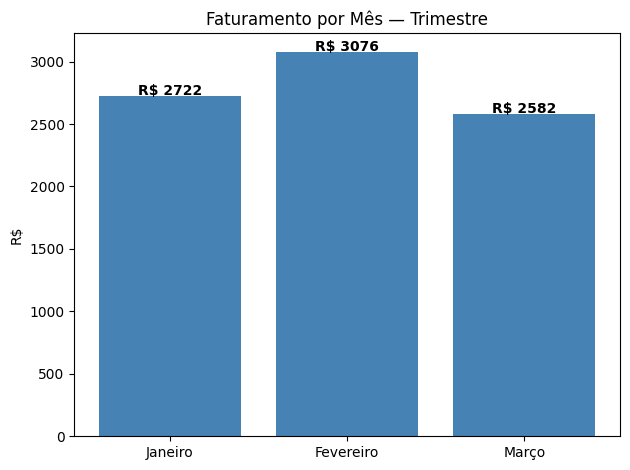

In [31]:
# Faturamento por mês após concatenação
df_trimestre['Mes'] = df_trimestre['Data'].dt.month
vendas_mes = df_trimestre.groupby('Mes')['Valor Líquido'].sum()

plt.bar(['Janeiro', 'Fevereiro', 'Março'], vendas_mes.values, color='steelblue')
for i, v in enumerate(vendas_mes.values):
    plt.text(i, v + 10, f'R$ {v:.0f}', ha='center', fontweight='bold')
plt.title('Faturamento por Mês — Trimestre')
plt.ylabel('R$')
plt.tight_layout()
plt.show()

---
## Exercício Final

Use a base `base_vendas_supermercado.xlsx` e siga os passos abaixo:

**1. Preparação (dados sujos)**
Crie uma cópia suja da base com:
- 10 NaN na coluna `'Categoria'`
- 8 NaN na coluna `'Quantidade'`
- 3 valores absurdos em `'Valor Líquido'` (ex: 5000, 4500, 0.01)
- 5 linhas duplicadas

**2. Diagnóstico**
Exiba:
- Percentual de NaN por coluna
- Quantidade de duplicatas

**3. Limpeza**
Aplique o pipeline completo:
- Remover duplicatas
- Preencher NaN de `'Categoria'` com a moda
- Preencher NaN de `'Quantidade'` com a mediana
- Filtrar `'Valor Líquido'` para o intervalo R$ 1 a R$ 300

**4. Transformações**
- Crie a coluna `'Mês_Num'` com o número do mês
- Crie a coluna `'Perfil_Compra'` usando `pd.cut()` com 3 faixas de `'Valor Líquido'`

**5. Gráfico final**
Plote um gráfico de barras com o total de vendas por `'Categoria'`, ordenado do maior para o menor.

## Gabarito — Pontos Principais

### Passo 1 — Criando dados sujos
```python
np.random.seed(42)
df_raw = df.copy()

for col, n in [('Categoria', 10), ('Quantidade', 8)]:
    idx = np.random.choice(df_raw.index, n, replace=False)
    df_raw.loc[idx, col] = np.nan

idx_out = np.random.choice(df_raw.index, 3, replace=False)
df_raw.loc[idx_out, 'Valor Líquido'] = [5000, 4500, 0.01]

dup = df_raw.sample(5, random_state=1)
df_raw = pd.concat([df_raw, dup], ignore_index=True)
```

### Passo 3 — Pipeline de limpeza
```python
df_clean = df_raw.drop_duplicates()
df_clean['Categoria'] = df_clean['Categoria'].fillna(df_clean['Categoria'].mode()[0])
df_clean['Quantidade'] = df_clean['Quantidade'].fillna(df_clean['Quantidade'].median())
df_clean = df_clean[(df_clean['Valor Líquido'] >= 1) & (df_clean['Valor Líquido'] <= 300)]
```

### Passo 4 — Transformações
```python
df_clean['Mês_Num'] = df_clean['Data'].dt.month
df_clean['Perfil_Compra'] = pd.cut(
    df_clean['Valor Líquido'],
    bins=[0, 25, 80, 300],
    labels=['Pequeno', 'Médio', 'Grande']
)
```

### Passo 5 — Gráfico por categoria
```python
vendas_cat = df_clean.groupby('Categoria')['Valor Líquido'].sum().sort_values(ascending=False)
plt.barh(vendas_cat.index, vendas_cat.values, color='steelblue')
plt.title('Total de Vendas por Categoria')
plt.xlabel('R$')
plt.tight_layout()
plt.show()
```

---
## Resumo da Aula

Hoje você aprendeu o fluxo completo de limpeza e preparação de dados:

| O que aprendeu | Como fazer |
|---|---|
| Detectar NaN | `isnull().sum()` |
| Tratar NaN (texto) | `fillna(moda)` |
| Tratar NaN (número) | `fillna(mediana)` |
| Remover NaN crítico | `dropna(subset=[...])` |
| Detectar duplicatas | `duplicated()` |
| Remover duplicatas | `drop_duplicates()` |
| Ver outliers | `boxplot` visual |
| Remover outliers | filtro com `>=` e `<=` |
| Extrair data | `.dt.month`, `.dt.day_name()` |
| Transformar coluna | `apply(lambda x: ...)` |
| Criar faixas | `pd.cut()` |
| Juntar tabelas | `pd.concat()` |

---
**Próxima semana:** Visualizações com Matplotlib e Seaborn — gráficos profissionais para apresentar seus dados.

In [32]:
print(df_sujo.values)

[[Timestamp('2026-03-14 00:00:00') 'Loja Centro' 'Empresa' ... 0.7 6.32
  'Pix']
 [Timestamp('2026-05-01 00:00:00') 'Loja Centro' 'Cliente Final' ... 0.2
  6.45 'Pix']
 [Timestamp('2026-01-31 00:00:00') 'Loja Bairro Alto' 'Cliente Final' ...
  5.25 69.69 'Cartão de Débito']
 ...
 [Timestamp('2026-04-21 00:00:00') 'Loja Shopping' 'Empresa' ... 9.7
  128.9 'Pix']
 [Timestamp('2026-03-03 00:00:00') 'Loja Shopping' 'Clube Fidelidade' ...
  9.71 87.35 'Cartão de Débito']
 [Timestamp('2026-04-18 00:00:00') 'Loja Shopping' 'Clube Fidelidade' ...
  1.61 14.5 'Dinheiro']]
